<a href="https://colab.research.google.com/github/ASaragga/GRF/blob/main/VaR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nota: Por vezes aparecem umas mensagens resultantes de uma brincadeira que o Google Colab decidiu fazer no dia 1 Abril de 2024, mas que mantém. Podemos retirar essas interrupções em Settings > Miscellaneous > Power Level, escolhendo: No Power

# Instalação

Vamos instalar as bibliotecas:  `Caramelo.j` e `HypothesisTests.jl`.

`Plots.jl` a biblioteca de gráficos que iremos também utilizar, faz parte do muito reduzido conjunto de bibliotecas que já vêm instaladas no Google Colab, não sendo por isso necessário fazer Pkg.add("Plots")

In [ ]:
import Pkg
Pkg.add(url="https://github.com/ASaragga/Caramel.jl")
Pkg.add("HypothesisTests");

    Updating git-repo `https://github.com/ASaragga/Caramel.jl`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [ ]:
using Caramel
using HypothesisTests
using Plots

Podemos guardar os gráficos criados por Plots, fazendo: `savefig(grafico, "nome_ficheiro")`

Exemplo: `savefig(grf01, "output.png")`

# Obtenção de Cotações e Visualização

Pretendemos obter as cotações diárias (ajustadas) de fecho da Apple, entre 1 Outubro 2020 e 15 de Março de 2025. Podemos, claro, escolher outras ações e períodos!

Para ações cotadas na Euronext Lisbon devemos acrescentar o sufixo (.LS) referente à bolsa,  e.g. "JMT.LS" para as ações da Jerónimo Martins.

In [ ]:
simbolo = "AAPL"                # "AAPL" é o símbolo da Apple na bolsa NASDAQ

preços = AssetPrice(simbolo, Date(2020,10,01), Date(2025,03,15)) |> DataFrame
show(preços)

1118×3 DataFrame
  Row │ ticker  date        adjclose
      │ String  Date        Float64
──────┼──────────────────────────────
    1 │ AAPL    2020-10-01   113.882
    2 │ AAPL    2020-10-02   110.206
    3 │ AAPL    2020-10-05   113.599
    4 │ AAPL    2020-10-06   110.342
    5 │ AAPL    2020-10-07   112.214
    6 │ AAPL    2020-10-08   112.107
    7 │ AAPL    2020-10-09   114.057
    8 │ AAPL    2020-10-12   121.302
    9 │ AAPL    2020-10-13   118.084
   10 │ AAPL    2020-10-14   118.172
   11 │ AAPL    2020-10-15   117.704
  ⋮   │   ⋮         ⋮          ⋮
 1109 │ AAPL    2025-03-03   238.03
 1110 │ AAPL    2025-03-04   235.93
 1111 │ AAPL    2025-03-05   235.74
 1112 │ AAPL    2025-03-06   235.33
 1113 │ AAPL    2025-03-07   239.07
 1114 │ AAPL    2025-03-10   227.48
 1115 │ AAPL    2025-03-11   220.84
 1116 │ AAPL    2025-03-12   216.98
 1117 │ AAPL    2025-03-13   209.68
 1118 │ AAPL    2025-03-14   213.49
                    1097 rows omitted

Selecionamos todas as linhas (:) mas apenas a coluna `:adjclose` para criar um vector contendo somente as cotações de fecho ajustadas em vez da totalidade do dataframe que tinhamos antes

In [ ]:
adjclose = preços[:, :adjclose];
# O ponto e virgula no final, faz com que o resultado do comando não seja impresso.


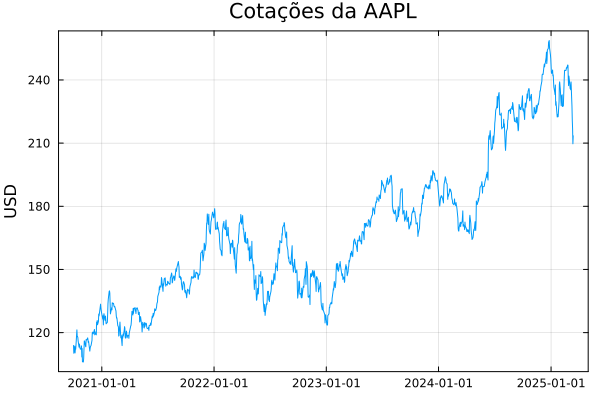

In [ ]:
fig1 = plot(preços[:,:date], adjclose, title="Cotações da $(simbolo)",legend = false,ylabel="USD", framestyle = :box)

# $(a) faz a interpolação do valor da variavel (a) no texto.

# Calcular Retornos

Para analisar séries cronológicas é normalmente mais indicado a utilização de retornos logarítmicos: $\log(P_t/P_{t-1})$. Julia denota por $\log(\cdot)$ a função que calcula o logarítmo de base e. Para agregação sectional, por exemplo se pretendermos calcular o retorno de uma carteira, devemos antes utilizar os retornos simples dos ativos constituintes da carteira: $(P_t-P_{t-1})/P_{t-1}$

In [ ]:
# Agora que inspecionámos a evolução das cotações, vamos calcular os retornos

logr = LogReturn(simbolo, Date(2020,10,01),Date(2025,01,01)) |> DataFrame
show(logr)

1068×5 DataFrame
  Row │ ticker  date        interval  type    returns
      │ String  Date        String    String  Float64
──────┼─────────────────────────────────────────────────
    1 │ AAPL    2020-10-02  1d        log     -0.032813
    2 │ AAPL    2020-10-05  1d        log      0.030326
    3 │ AAPL    2020-10-06  1d        log     -0.029088
    4 │ AAPL    2020-10-07  1d        log      0.016825
    5 │ AAPL    2020-10-08  1d        log     -0.000956
    6 │ AAPL    2020-10-09  1d        log      0.017246
    7 │ AAPL    2020-10-12  1d        log      0.061585
    8 │ AAPL    2020-10-13  1d        log     -0.026886
    9 │ AAPL    2020-10-14  1d        log      0.000743
   10 │ AAPL    2020-10-15  1d        log     -0.003969
   11 │ AAPL    2020-10-16  1d        log     -0.014099
  ⋮   │   ⋮         ⋮          ⋮        ⋮         ⋮
 1059 │ AAPL    2024-12-17  1d        log      0.009673
 1060 │ AAPL    2024-12-18  1d        log     -0.021655
 1061 │ AAPL    2024-12-19  1d        

In [ ]:
# Selecionamos todas as linhas do dataframe (logr) e apenas a coluna :returns

returns = logr[:, :returns];

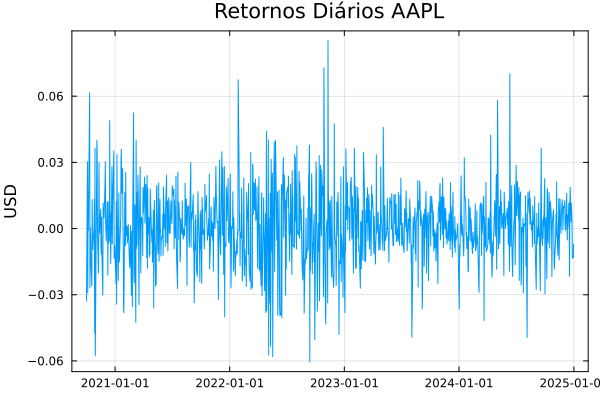

In [ ]:
fig2 = plot(logr[:,:date], returns, title="Retornos Diários $(simbolo)",legend = false, ylabel="USD", framestyle = :box)

## Média e Volatilidade

Iremos calcular de seguida (i) a média (μ) e o (ii) desvio-padrão (σ) dos retornos diários,

In [ ]:
mu = mean(returns)
sigma = std(returns)
println("μ = ", mu)
println("σ = ", sigma)

μ = 0.0007367762172284645
σ = 0.01706993314124558


Podemos obter algumas estatísticas adicionais de sumarização relativamente aos retornos usando o método `describe`.

In [ ]:
describe(returns)

Summary Stats:
Length:         1068
Missing Count:  0
Mean:           0.000737
Std. Deviation: 0.017070
Minimum:        -0.060472
1st Quartile:   -0.008214
Median:         0.001095
3rd Quartile:   0.010287
Maximum:        0.085236
Type:           Float64


## Histograma

Podemos visualizar o histograma dos retorns diário usando o método `histogram()` da bilioteca Plots.jl

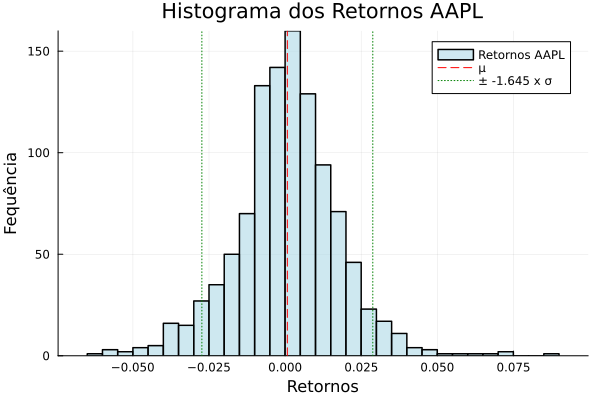

In [ ]:
fig3 = histogram(returns,
          bins=30,  # Numero de barras
          color=:lightblue,
          label="Retornos $(simbolo)",
          xlabel="Retornos",
          ylabel="Fequência",
          title="Histograma dos Retornos $(simbolo)",
          grid=true,
          fillalpha=0.6,  # Transparencia das barras
          linecolor=:black,
          linewidth=1.5)

# Adicionamos linhas verticais (vline!) para a média e z * desvio-padrão

z = - 1.645   # quantil a 5% se distribuição normal(0,1)

vline!([mu], linecolor=:red, linestyle=:dash, label="μ")
vline!([mu + z * sigma, mu - z * sigma],
       linecolor=:green, linestyle=:dot, label="± $(z) x σ")

display(plot!(fig3))

O gráfico (fig3) sugere que a observação de valores extremos ocorreu com elevada frequência

# Testes de Normalidade

Em que medida uma distribuição normal representa bem a realidade empírica dos retornos observados nos últimos anos?
*   Inspeção Visual
  * $\surd$ Histograma
  * Gráficos Quantil-Quantil (não existe em Plots.jl)
*   Testes Estatísticos de Normalidade
  * Teste de Jarque-Bera
  * Teste de Shapiro-Wilk
  * Teste de Anderson-Darling (não existe em HypothesisTests.jl)





Aqui, usamos a bibioteca de testes estatísticos `HypothesisTests.jl`

Hipótese nula: os retornos têm uma distribuição normal

In [ ]:
jb_test = JarqueBeraTest(returns)
println("Teste Jarque-Bera valores-p: ", pvalue(jb_test))

sw_test = ShapiroWilkTest(returns)
println("Teste Shapiro-Wilk valores-p: ", pvalue(sw_test))

Teste Jarque-Bera valores-p: 2.3812037497722555e-33
Teste Shapiro-Wilk valores-p: 4.5283586250436116e-11


Estes valores-p são realmente extremamente pequenos! Com o teste de Jarque-Bera (valor-p ≈ 2,37e-33) e o teste de Shapiro-Wilk (valor-p ≈ 4,53e-11) mostrando resultados tão significativos, temos evidência muito forte para rejeitar a hipótese nula de normalidade para os retornos da Apple.
Isto é bastante comum com dados de retornos de ações, que tipicamente apresentam:
*   Excesso de  kurtosis (caudas pesadas) - eventos extremos acontecem com mais frequência do que uma distribuição normal preveria
* Leve assimetria negativa - grandes retornos negativos tendem a ser mais extremos que grandes retornos positivos

Uma vez que rejeitámos a normalidade, ajustar uma distribuição T-Student será um bom próximo passo. Como sabemos, a distribuição T-Student pode acomodar estas caudas pesadas através do seu parâmetro de graus de liberdade ($ν$). Valores mais baixos de ($ν$) indicam caudas mais pesadas.

# Optimizar o Ajustamento da Distribuição dos Retornos
- Normal
- T-Student



## Distribuição Normal

Primeiro ajustamos a distribuição Normal aos retornos observados, o que é muito simples

In [ ]:
μ, σ = mean(returns), std(returns)
normal_fit = Normal(μ, σ)
println("Parâmetros: ", normal_ajs)


Parâmetros: Normal{Float64}(μ=0.00037780183486238537, σ=0.016451558832228673)


## Distribuição T-Student

Ajustamos agora a distribuição T de Student aos retornos obervados. Em particular, estaremos interessados em determinar o número óptimos de graus de liberdade ($ν$). A T-Student é parametrizada por: ($ν$) graus de liberdade, (μ) média, e (s) escala. De facto, para a T-Student, a relação entre o desvio-padrão (σ), parâmetro de escala (s) e graus de liberdade ($v$), é dada por,
$$\sigma = s \cdot \sqrt{v\,/\,(v-2)}$$
O Caramel faz o ajustamento à T-Student através do método de máxima verosimilhança.

In [ ]:
ν_fit, μ_fit, s_fit = Caramel.fit_mle(TDist, returns)
ν_fit = Int(round(ν_fit))
println("Parâmetros: ν = ", ν_fit, ", μ = ", μ_fit, ", s = ", s_fit)

Parâmetros: ν = 5, μ = 0.0008977622585589893, s = 0.013407098091282514


## Validação do Ajustamento Óptimo da T-Student

In [ ]:
𝜎_fit = s_fit * sqrt(ν_fit / (ν_fit-2.0))
println("Desvio-padrão da T-Student ajustada = ", 𝜎_fit)

println("Desvio-padrão da amostra = ", σ)

Desvio-padrão da T-Student ajustada = 0.01730848920950214
Desvio-padrão da amostra = 0.01706993314124558


Se o desvio padrão da amostra for muito diferente do da distribuição ajustada, os parâmetros estimados provavelmente estarão incorretos, e deveremos rever o processo de optimização utilizado pelo Caramel: Fminbox(LBFGS()).

# Histograma Empírico com Distribuições Ajustadas Sobrepostas

Vamos criar um gráfico (fig4) que sobrepõe ao histograma com a distrubuição empírica de retornos (fig3) as funções de densidade de probabilidade com ajustamento óptimo que determinámos para as distribuições Normal e T-Student.

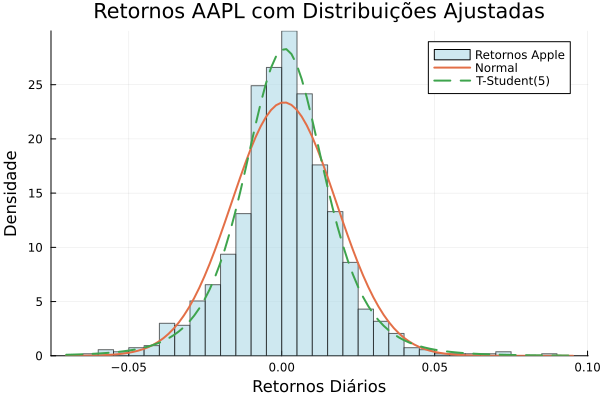

In [ ]:
# T-Student
t_fit = LocationScale(μ_fit, s_fit, TDist(ν_fit))  # Usamos LocationScale para obter deslocamento/escala adequados

# Histograma com a distribuição empírica
histogram(returns, bins=30, color=:lightblue, normalize=:pdf, label="Retornos Apple", alpha=0.6)

# Sobrepomos a distribuição Normal ajustada
x_range = range(minimum(returns) - 0.01, maximum(returns) + 0.01, length=100)  # Extendemos o x_range por razões de estética...
plot!(x_range, pdf.(normal_fit, x_range), label="Normal", linewidth=2)

# Sobrepomos a distribuição T-Student óptima ajustada
fig4 = plot!(x_range, pdf.(t_fit, x_range), label="T-Student($ν_fit)", linewidth=2, linestyle=:dash)

title!("Retornos $(simbolo) com Distribuições Ajustadas")
xlabel!("Retornos Diários")
ylabel!("Densidade")

# Valor-em-Risco (VaR)

## Abordagem Analítica

Vamos agora determinar o valor em risco de acordo com a abordagem analítica.
1.   Escolhemos a distribuição de probabilidades.
2.   Selecionamos o período da amostra e estimamos o desvio-padrão ($\sigma_p$) da distribuição escolhida com base nos dados da amostra
  *   Podemos também considerar o valor esperado dos retornos $\mathbb{E}[\mu]$ com base num modelo de equilíbrio forward-looking, como CAPM.
  *   Pelo contrário, normalmente a volatilidade é estimada com base em dados históricos.
3.   Com base na distribução escolhida, calculamos o $\alpha$-quantil ($z_\alpha$) desejado.

Iremos considerar que $\mathbb{E}[\mu]\approx 0$, donde que neste caso teremos que

$$\text{VaR}_\alpha = - z_\alpha * \sigma_p * V_p$$

onde $V_p$ é o valor do portfolio.

No nosso exemplo, iremos calcular o VaR utilizando a distribuição T-Student com os graus de liberdade que permitem o ajustamento óptimi, i.e. `ν_fit`, que já calculámos. Qual será o VaR diário para uma carteira (V) de USD 100 000, ao nível de significância 𝛼 = 5.0%?

In [ ]:
V = 100_000
𝛼 = 0.05

z_𝛼 = quantile(TDist(ν_fit),𝛼)
VaR = - z_𝛼 * 𝜎_fit * V
println("Abordagem Analítica com T-Student($ν_fit): VaR(𝛼=$(𝛼)) = ", VaR)

Abordagem Analítica com T-Student(5): VaR(𝛼=0.05) = 3487.7443026459473


E qual seria o VaR se tivéssemos utilizado a Distribuição Normal?

In [ ]:
z_𝛼 = quantile(Normal(),𝛼)
VaR = - z_𝛼 * σ * V
println("Abordagem Analítica com Normal: VaR(𝛼=$(𝛼)) = ", VaR)

Abordagem Analítica com Normal: VaR(𝛼=0.05) = 2807.754143919694


# Simulação Histórica

O cálculo do VaR por simulação histórica requer apenas que determinemos o ponto de corte correspondente ao $\alpha$-quantil para o período da amostra.

In [ ]:
VaR = - quantile(returns, 𝛼) * V
println("Simulação Histórica: VaR(𝛼=$(𝛼)) = ", VaR)

Simulação Histórica: VaR(𝛼=0.05) = 2757.535
